# Notebook to test things on classifying images by their confidence results 

In [ ]:
# imports
from pathlib import Path
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import normalize

from sklearn.model_selection import GridSearchCV
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA




pd.set_option('display.max_colwidth', None)

In [21]:
# consts

DATA_DIR = Path("./data")
DATABASE_DIR = Path("../../databases/full databases")
PROCESS_FOLDER_DIR = Path("../process_folder")
PROCESS_FOLDER_RESULTS = PROCESS_FOLDER_DIR / "results_4.csv"
RESULTS_DIR = Path("./results")

INSECTS = ["coleoptera", "diptera", "hymenoptera", "lepidoptera"]

POINTS = ['head-top', 'head-left', 'head-right', 'left-eye', 'right-eye', 'neck', 'thorax-left', 'thorax-right', 'thorax-bottom', 'body-left', 'body-right', 'body-tip', 'left-antenna-0', 'left-antenna-1', 'left-antenna-2', 'right-antenna-0', 'right-antenna-1', 'right-antenna-2', 'left-forewing-base', 'left-forewing-tip', 'left-forewing-front', 'left-forewing-rear', 'right-forewing-base', 'right-forewing-tip', 'right-forewing-front', 'right-forewing-rear', 'left-hindwing-base', 'left-hindwing-tip', 'left-hindwing-front', 'left-hindwing-rear', 'right-hindwing-base', 'right-hindwing-tip', 'right-hindwing-front', 'right-hindwing-rear', 'left-leg-0', 'left-leg-1', 'left-leg-2', 'left-leg-3', 'right-leg-0', 'right-leg-1', 'right-leg-2', 'right-leg-3']

MEAS_TO_KP = {
    "total length":                ["head-top", "neck", "thorax-bottom", "body-tip"],
    "head width":                  ["head-left", "head-right"],
    "head length":                 ["head-top", "neck"],
    "inter ocular distance":       ["right-eye", "left-eye"],
    "right antenna length":        ["right-antenna-0", "right-antenna-1", "right-antenna-2"],
    "left antenna length":         ["left-antenna-0", "left-antenna-1", "left-antenna-2"],
    "thorax width":                ["thorax-left", "thorax-right"],
    "thorax length":               ["neck", "thorax-bottom"],
    "abdomen width":               ["body-left", "body-right"],
    "abdomen length":              ["thorax-bottom", "body-tip"],
    "intertegular distance":       ["left-forewing-base", "right-forewing-base"],
    "left hind wing length":       ["left-hindwing-base", "left-hindwing-tip"],
    "right hind wing length":      ["right-hindwing-base", "right-hindwing-tip"],
    "left hind wing width":        ["left-hindwing-front", "left-hindwing-rear"],
    "right hind wing width":       ["right-hindwing-front", "right-hindwing-rear"],
    "left fore wing length":       ["left-forewing-base", "left-forewing-tip"],
    "right fore wing length":      ["right-forewing-base", "right-forewing-tip"],
    "left fore wing width":        ["left-forewing-front", "left-forewing-rear"],
    "right fore wing width":       ["right-forewing-front", "right-forewing-rear"],
    "left hind leg length":        ["left-leg-0", "left-leg-1", "left-leg-2", "left-leg-3"],
    "left hind leg femur length":  ["left-leg-0", "left-leg-1"],
    "left hind leg tibia length":  ["left-leg-1", "left-leg-2"],
    "left hind leg tarsus length": ["left-leg-2", "left-leg-3"],
    "right hind leg length":       ["right-leg-0", "right-leg-1", "right-leg-2", "right-leg-3"],
    "right hind leg femur length": ["right-leg-0", "right-leg-1"],
    "right hind leg tibia length": ["right-leg-1", "right-leg-2"],
    "right hind leg tarsus length":["right-leg-2", "right-leg-3"],
}

KP_TO_MEAS = {
    point : [] for point in POINTS
}
for meas, points in MEAS_TO_KP.items():
    for p in points:
        if meas not in KP_TO_MEAS[p]:
            KP_TO_MEAS[p].append(meas)

GROUP_TO_KP = {
    "head" : ["head-top", "head-left", "head-right", "neck", "left-eye", "right-eye", "right-antenna-0", "left-antenna-0"],
    "thorax" : ["neck", "thorax-left", "thorax-right", "thorax-bottom", "left-forewing-base", "right-forewing-base", "right-hindwing-base", "left-hindwing-base"],
    "body" : ["thorax-bottom", "body-left", "body-right", "body-tip", "left-leg-0", "right-leg-0"],
    "right-antenna" : ["right-antenna-0", "right-antenna-1", "right-antenna-2"],
    "left-antenna" : ["left-antenna-0", "left-antenna-1", "left-antenna-2"],
    "left-forewing" : ["left-forewing-base", "left-forewing-tip", "left-forewing-front", "left-forewing-rear"],
    "right-forewing" : ["right-forewing-base", "right-forewing-tip", "right-forewing-front", "right-forewing-rear"],
    "left-hindwing" : ["left-hindwing-base", "left-hindwing-tip", "left-hindwing-front", "left-hindwing-rear"],
    "right-hindwing" : ["right-hindwing-base", "right-hindwing-tip", "right-hindwing-front", "right-hindwing-rear"],
    "right-leg" : ["right-leg-0", "right-leg-1", "right-leg-2", "right-leg-3"],
    "left-leg" : ["left-leg-0", "left-leg-1", "left-leg-2", "left-leg-3"],
}

KP_TO_GROUP = {
    point : [] for point in POINTS
}
for group, points in GROUP_TO_KP.items():
    for p in points:
        if group not in KP_TO_GROUP[p]:
            KP_TO_GROUP[p].append(group)
print(KP_TO_GROUP)


{'head-top': ['head'], 'head-left': ['head'], 'head-right': ['head'], 'left-eye': ['head'], 'right-eye': ['head'], 'neck': ['head', 'thorax'], 'thorax-left': ['thorax'], 'thorax-right': ['thorax'], 'thorax-bottom': ['thorax', 'body'], 'body-left': ['body'], 'body-right': ['body'], 'body-tip': ['body'], 'left-antenna-0': ['head', 'left-antenna'], 'left-antenna-1': ['left-antenna'], 'left-antenna-2': ['left-antenna'], 'right-antenna-0': ['head', 'right-antenna'], 'right-antenna-1': ['right-antenna'], 'right-antenna-2': ['right-antenna'], 'left-forewing-base': ['thorax', 'left-forewing'], 'left-forewing-tip': ['left-forewing'], 'left-forewing-front': ['left-forewing'], 'left-forewing-rear': ['left-forewing'], 'right-forewing-base': ['thorax', 'right-forewing'], 'right-forewing-tip': ['right-forewing'], 'right-forewing-front': ['right-forewing'], 'right-forewing-rear': ['right-forewing'], 'left-hindwing-base': ['thorax', 'left-hindwing'], 'left-hindwing-tip': ['left-hindwing'], 'left-hindw

## getting data from csv

In [22]:
# load each csv in the ./data folder and combine them into a single dataframe
dfs = [pd.read_csv(f) for f in DATA_DIR.glob("*.csv")]
df = pd.concat(dfs, ignore_index=True)

df.head()

,image,total length_status,head width_status,head length_status,inter ocular distance_status,right antenna length_status,left antenna length_status,thorax width_status,thorax length_status,abdomen width_status,...,left fore wing width_px,right fore wing width_px,left hind leg length_px,left hind leg femur length_px,left hind leg tibia length_px,left hind leg tarsus length_px,right hind leg length_px,right hind leg femur length_px,right hind leg tibia length_px,right hind leg tarsus length_px
0,C:\Users\tombe\Documents\_MLE\CV-for-GRIT\databases\hawaii_beetles_images\individual_specimens\01\IMG_0093_specimen_1_MECKON_NEON.BET.D20.000001.png,measurable,measurable,measurable,measurable,measurable,measurable,measurable,measurable,measurable,...,77.737,65.087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,C:\Users\tombe\Documents\_MLE\CV-for-GRIT\databases\hawaii_beetles_images\individual_specimens\01\IMG_0093_specimen_3_MECKON_NEON.BET.D20.000004.png,measurable,measurable,measurable,measurable,measurable,measurable,measurable,measurable,measurable,...,68.969,51.511,NaN,NaN,70.455,48.522,NaN,NaN,NaN,NaN
2,C:\Users\tombe\Documents\_MLE\CV-for-GRIT\databases\hawaii_beetles_images\individual_specimens\01\IMG_0095_specimen_2_MECKON_NEON.BET.D20.000007.png,measurable,measurable,measurable,measurable,measurable,measurable,measurable,measurable,measurable,...,64.634,55.961,NaN,NaN,NaN,NaN,NaN,NaN,65.459,33.984
3,C:\Users\tombe\Documents\_MLE\CV-for-GRIT\databases\hawaii_beetles_images\individual_specimens\01\IMG_0095_specimen_3_MECKON_NEON.BET.D20.000010.png,measurable,measurable,measurable,measurable,measurable,measurable,measurable,measurable,measurable,...,85.635,67.770,NaN,NaN,NaN,NaN,NaN,NaN,101.337,61.556
4,C:\Users\tombe\Documents\_MLE\CV-for-GRIT\databases\hawaii_beetles_images\individual_specimens\01\IMG_0109_specimen_1_MECKON_NEON.BET.D20.000011.png,measurable,measurable,measurable,measurable,measurable,measurable,measurable,measurable,measurable,...,75.599,63.938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# preparation of data
# change image path with the equivalent in DATABASE_DIR, by finding the stem in the folders in DATABSE_DIR

REPLACE_BY_FULL_PATH = False

OH_coleoptera = []
OH_diptera  = []
OH_hymenoptera = []
OH_lepidoptera = []

for i, row in df.iterrows():

    # get the stem of the image path
    stem = Path(row["image"]).stem

    found = False
    # find the folder in DATABASE_DIR that contains the stem
    for folder in DATABASE_DIR.iterdir():
        if folder.is_dir() and any((folder / f"{stem}{ext}").exists() for ext in [".jpg", ".jpeg", ".png", ".JPG"]):
            if (folder / f"{stem}.jpg").exists():
                ext = "jpg"
            elif (folder / f"{stem}.jpeg").exists():
                ext = "jpeg"
            elif (folder / f"{stem}.png").exists():
                ext = "png"
            elif (folder / f"{stem}.JPG").exists():
                ext = "JPG"
            else:
                print("error : AZEYGDH")

            folder_name = folder.name
            if folder_name == "coleoptera":
                OH_coleoptera.append(1)
                OH_diptera.append(0)
                OH_hymenoptera.append(0)
                OH_lepidoptera.append(0)
            elif folder_name == "diptera":
                OH_coleoptera.append(0)
                OH_diptera.append(1)
                OH_hymenoptera.append(0)
                OH_lepidoptera.append(0)
            elif folder_name == "hymenoptera":
                OH_coleoptera.append(0)
                OH_diptera.append(0)
                OH_hymenoptera.append(1)
                OH_lepidoptera.append(0)     
            elif folder_name == "lepidoptera":
                OH_coleoptera.append(0)
                OH_diptera.append(0)
                OH_hymenoptera.append(0)
                OH_lepidoptera.append(1)
            else:
                print(folder, "is not coleoptera, diptera, hymenoptera or lepidoptera")

            if REPLACE_BY_FULL_PATH:
                df.at[i, "image"] = str(folder / f"{stem}.{ext}")
            else:
                df.at[i, "image"] = f"{stem}.{ext}"

            found = True
            break

df.insert(1, "coleoptera_one_hot", OH_coleoptera)
df.insert(1, "diptera_one_hot", OH_diptera)
df.insert(1, "hymenoptera_one_hot", OH_hymenoptera)
df.insert(1, "lepidoptera_one_hot", OH_lepidoptera)
df.head()


,image,lepidoptera_one_hot,hymenoptera_one_hot,diptera_one_hot,coleoptera_one_hot,total length_status,head width_status,head length_status,inter ocular distance_status,right antenna length_status,...,left fore wing width_px,right fore wing width_px,left hind leg length_px,left hind leg femur length_px,left hind leg tibia length_px,left hind leg tarsus length_px,right hind leg length_px,right hind leg femur length_px,right hind leg tibia length_px,right hind leg tarsus length_px
0,IMG_0093_specimen_1_MECKON_NEON.BET.D20.000001.png,0,0,0,1,measurable,measurable,measurable,measurable,measurable,...,77.737,65.087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IMG_0093_specimen_3_MECKON_NEON.BET.D20.000004.png,0,0,0,1,measurable,measurable,measurable,measurable,measurable,...,68.969,51.511,NaN,NaN,70.455,48.522,NaN,NaN,NaN,NaN
2,IMG_0095_specimen_2_MECKON_NEON.BET.D20.000007.png,0,0,0,1,measurable,measurable,measurable,measurable,measurable,...,64.634,55.961,NaN,NaN,NaN,NaN,NaN,NaN,65.459,33.984
3,IMG_0095_specimen_3_MECKON_NEON.BET.D20.000010.png,0,0,0,1,measurable,measurable,measurable,measurable,measurable,...,85.635,67.770,NaN,NaN,NaN,NaN,NaN,NaN,101.337,61.556
4,IMG_0109_specimen_1_MECKON_NEON.BET.D20.000011.png,0,0,0,1,measurable,measurable,measurable,measurable,measurable,...,75.599,63.938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
# preparation of data
# replacing measurable by 0 or 1
columns = list(df.columns.values)
for col in columns :
    if "status" in col:
        df[col] = df[col].apply(lambda x:  1 * (x.strip() == "measurable"))

df.rename(columns={"image" : "image_name"}, inplace=True)
print(df["total length_status"].unique())

[1 0]


## get data from process_file_folder

In [25]:
rdf = pd.read_csv(PROCESS_FOLDER_RESULTS)

rdf.fillna(rdf.dtypes.replace({"str" :  "-", "int64" : 0, "float64": 0., "object" : "-"}), inplace=True)

for col in list(rdf.columns.values):
    if col not in ["image_name", "scale_method", 'in_train', 'in_val']:
        rdf[col] = (rdf[col]-rdf[col].min())/(rdf[col].max()-rdf[col].min())

rdf.head()

,image_name,in_train,in_val,total length [px],head width [px],head length [px],inter ocular distance [px],right antenna length [px],left antenna length [px],thorax width [px],...,right-leg-0 [kp_conf],right-leg-1 [kp_x],right-leg-1 [kp_y],right-leg-1 [kp_conf],right-leg-2 [kp_x],right-leg-2 [kp_y],right-leg-2 [kp_conf],right-leg-3 [kp_x],right-leg-3 [kp_y],right-leg-3 [kp_conf]
0,HP.578.jpg,0,0,0.042287,0.027773,0.029147,0.028742,0.016944,0.030244,0.025301,...,0.001727,0.037456,0.015796,0.406935,0.042968,0.016833,0.079327,0.050237,0.022135,0.037509
1,GJ.2753.jpg,1,0,0.325460,0.225982,0.250815,0.024988,0.036106,0.047424,0.204353,...,0.000914,0.106468,0.428624,0.240302,0.073314,0.398258,0.034956,0.028776,0.324657,0.031090
2,HP.50.jpg,0,0,0.274108,0.227768,0.263011,0.190321,0.066795,0.065306,0.204051,...,0.138677,0.254816,0.318418,0.731357,0.231101,0.342487,0.119491,0.202633,0.322274,0.015645
3,HP.396.jpg,0,0,0.212923,0.154757,0.162313,0.025982,0.041057,0.048263,0.120827,...,0.000203,0.155468,0.063815,0.274472,0.181604,0.078854,0.029547,0.205286,0.075563,0.009227
4,HP.136.jpg,0,0,0.271816,0.195070,0.198626,0.319283,0.114325,0.117855,0.200971,...,0.010667,0.172577,0.058742,0.674472,0.224797,0.062350,0.334435,0.240641,0.062905,0.088657


## make the intersection between the tables

In [26]:
idf = pd.merge(df, rdf, how='inner', on=['image_name'])

idf.rename(columns ={x : x.replace("[", "").replace("]", "") for x in list(idf.columns.values)}, inplace=True)

print(len(idf), list(idf.columns.values))
idf.head()

1198 ['image_name', 'lepidoptera_one_hot', 'hymenoptera_one_hot', 'diptera_one_hot', 'coleoptera_one_hot', 'total length_status', 'head width_status', 'head length_status', 'inter ocular distance_status', 'right antenna length_status', 'left antenna length_status', 'thorax width_status', 'thorax length_status', 'abdomen width_status', 'abdomen length_status', 'intertegular distance_status', 'left hind wing length_status', 'right hind wing length_status', 'left hind wing width_status', 'right hind wing width_status', 'left fore wing length_status', 'right fore wing length_status', 'left fore wing width_status', 'right fore wing width_status', 'left hind leg length_status', 'left hind leg femur length_status', 'left hind leg tibia length_status', 'left hind leg tarsus length_status', 'right hind leg length_status', 'right hind leg femur length_status', 'right hind leg tibia length_status', 'right hind leg tarsus length_status', 'total length_px', 'head width_px', 'head length_px', 'inter

,image_name,lepidoptera_one_hot,hymenoptera_one_hot,diptera_one_hot,coleoptera_one_hot,total length_status,head width_status,head length_status,inter ocular distance_status,right antenna length_status,...,right-leg-0 kp_conf,right-leg-1 kp_x,right-leg-1 kp_y,right-leg-1 kp_conf,right-leg-2 kp_x,right-leg-2 kp_y,right-leg-2 kp_conf,right-leg-3 kp_x,right-leg-3 kp_y,right-leg-3 kp_conf
0,IMG_0093_specimen_1_MECKON_NEON.BET.D20.000001.png,0,0,0,1,1,1,1,1,1,...,0.003556,0.033488,0.107541,0.105427,0.030171,0.113113,0.039663,0.022727,0.099583,0.023869
1,IMG_0093_specimen_3_MECKON_NEON.BET.D20.000004.png,0,0,0,1,1,1,1,1,1,...,0.013411,0.032748,0.100158,0.240603,0.030357,0.106376,0.146234,0.023175,0.094465,0.089961
2,IMG_0095_specimen_2_MECKON_NEON.BET.D20.000007.png,0,0,0,1,1,1,1,1,1,...,0.002438,0.034906,0.105446,0.675276,0.031967,0.114187,0.761919,0.026808,0.100559,0.703841
3,IMG_0095_specimen_3_MECKON_NEON.BET.D20.000010.png,0,0,0,1,1,1,1,1,1,...,0.004165,0.042524,0.118859,0.508844,0.037281,0.126641,0.255108,0.029499,0.113468,0.184535
4,IMG_0109_specimen_1_MECKON_NEON.BET.D20.000011.png,0,0,0,1,1,1,1,1,1,...,0.012496,0.043737,0.078494,0.459698,0.038942,0.083388,0.269631,0.033061,0.074168,0.201183


## only keep interresting columns for models

In [55]:
def get_relations(values, base):
    related_val = []
    for p in values:
        vals = base.get(p, [])
        for v in vals:
            if v not in related_val:
                related_val.append(v)
    return related_val


def create_df(feature_group, n_pca=0, related_to_measure="", unique=False):
    """
    feature group : conf  / meas / pos / one_hot (or multiple, separated by coma)
    related_to_measure : name of the measurement
    """

    # prepare filters on the columns
    filter_map = {"conf" : ("kp_conf", ), "meas" : (" px", ), "pos" : ("kp_x", "kp_y"), "one_hot" : ("one_hot",)}
    filters_lists = [filter_map.get(x, None) for x in feature_group.split(",")]

    filters = []
    for l in filters_lists:
        for x in l:
            filters.append(x)

    if len(related_to_measure) > 0 :
        # prepare filter on the kp and measurement names
        rel_points = get_relations([related_to_measure], MEAS_TO_KP)
        rel_groups = get_relations(rel_points, KP_TO_GROUP)
        rel_dist_points  = get_relations(rel_groups, GROUP_TO_KP)
        rel_dist_meas = get_relations(rel_dist_points, KP_TO_MEAS)
        
        speci_filters = rel_dist_points + rel_dist_meas
    else:
        speci_filters = []

    def check_filter(x):
        if (not unique and (any([y in x for y in filters]) and \
        (len(speci_filters) == 0 or any([y in x for y in speci_filters])))) or \
            (unique and related_to_measure in x):
            return True
        return False

    # idf global
    df = idf[[x for x in list(idf.columns.values) if "status" in x or x == "image_name" or check_filter(x)]].copy()

    # if n_pca>0, run it
    if n_pca > 0:
        df_v = df[[x for x in list(idf.columns.values) if check_filter(x)]].copy()
        pca = PCA(n_components= n_pca)
        pca.fit(df_v)

        df_pca = pd.DataFrame(
            pca.transform(df_v),
            columns=['PC%s' % _ for _ in range(n_pca)],
            index=df_v.index
        )
        df = pd.concat([df.drop(columns=df_v.columns), df_pca], axis=1)

    return df

print(list(idf.columns.values))
df_one_hot = create_df("one_hot")
print(len(list(df_one_hot.columns.values)), list(df_one_hot.columns.values))

# 1 : only confidence
df1 = create_df("meas", related_to_measure="head length")
print(len(list(df1.columns.values)), list(df1.columns.values))



['image_name', 'lepidoptera_one_hot', 'hymenoptera_one_hot', 'diptera_one_hot', 'coleoptera_one_hot', 'total length_status', 'head width_status', 'head length_status', 'inter ocular distance_status', 'right antenna length_status', 'left antenna length_status', 'thorax width_status', 'thorax length_status', 'abdomen width_status', 'abdomen length_status', 'intertegular distance_status', 'left hind wing length_status', 'right hind wing length_status', 'left hind wing width_status', 'right hind wing width_status', 'left fore wing length_status', 'right fore wing length_status', 'left fore wing width_status', 'right fore wing width_status', 'left hind leg length_status', 'left hind leg femur length_status', 'left hind leg tibia length_status', 'left hind leg tarsus length_status', 'right hind leg length_status', 'right hind leg femur length_status', 'right hind leg tibia length_status', 'right hind leg tarsus length_status', 'total length_px', 'head width_px', 'head length_px', 'inter ocul

## test basic XGBoost model

In [28]:
# split

main_df = df1.copy()

train, test = train_test_split(main_df, test_size=0.2)

data_train = train[[x for x in list(main_df.columns.values) if "status" not in x and x != "image_name"]].copy()
data_test = test[[x for x in list(main_df.columns.values) if "status" not in x and x != "image_name"]].copy()
# test on head_length
label_train = train["head length_status"]
label_test = test["head length_status"]

In [29]:
model = XGBClassifier(random_state=42)
model.fit(data_train, label_train)

,"objective objective: str | xgboost.objective.Objective | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGB

In [30]:
y_pred_proba = model.predict_proba(data_test)[:, 1]

total length px :  0.042221796
head width px :  0.027106894
head length px :  0.12688218
inter ocular distance px :  0.026666887
right antenna length px :  0.022547107
left antenna length px :  0.023426853
thorax width px :  0.035759136
thorax length px :  0.05116
abdomen width px :  0.022658626
abdomen length px :  0.016228318
intertegular distance px :  0.067351095
left hind wing length px :  0.017676484
right hind wing length px :  0.017994579
left hind wing width px :  0.027941933
right hind wing width px :  0.1356215
left fore wing length px :  0.021323945
right fore wing length px :  0.017464938
left fore wing width px :  0.020964783
right fore wing width px :  0.018034335
left hind leg length px :  0.027320765
left hind leg femur length px :  0.02243719
left hind leg tibia length px :  0.0236665
left hind leg tarsus length px :  0.019458838
right hind leg length px :  0.036833122
right hind leg femur length px :  0.028800795
right hind leg tibia length px :  0.030004647
right hi

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

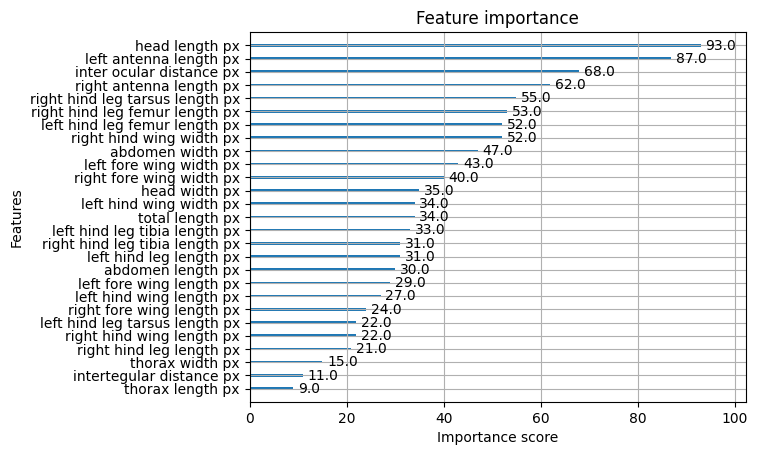

In [31]:
xgb_fea_imp=pd.DataFrame(list(model.get_booster().get_fscore().items()),
columns=['feature','importance']).sort_values('importance', ascending=False)
xgb_fea_imp.to_csv('xgb_fea_imp.csv')

feas = model.feature_importances_
colums   =list(data_train.columns.values)
for i in range(len(colums)):
    print(colums[i], ": ", feas[i])

from xgboost import plot_importance
plot_importance(model, )

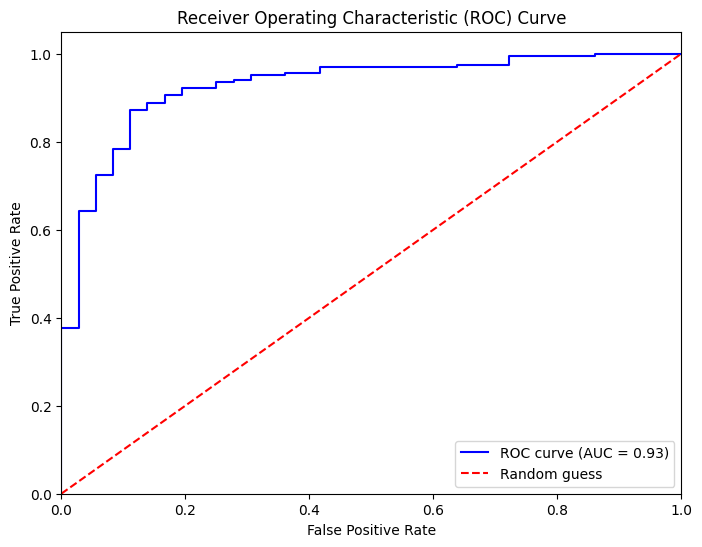

In [32]:
fpr, tpr, thresholds = roc_curve(label_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

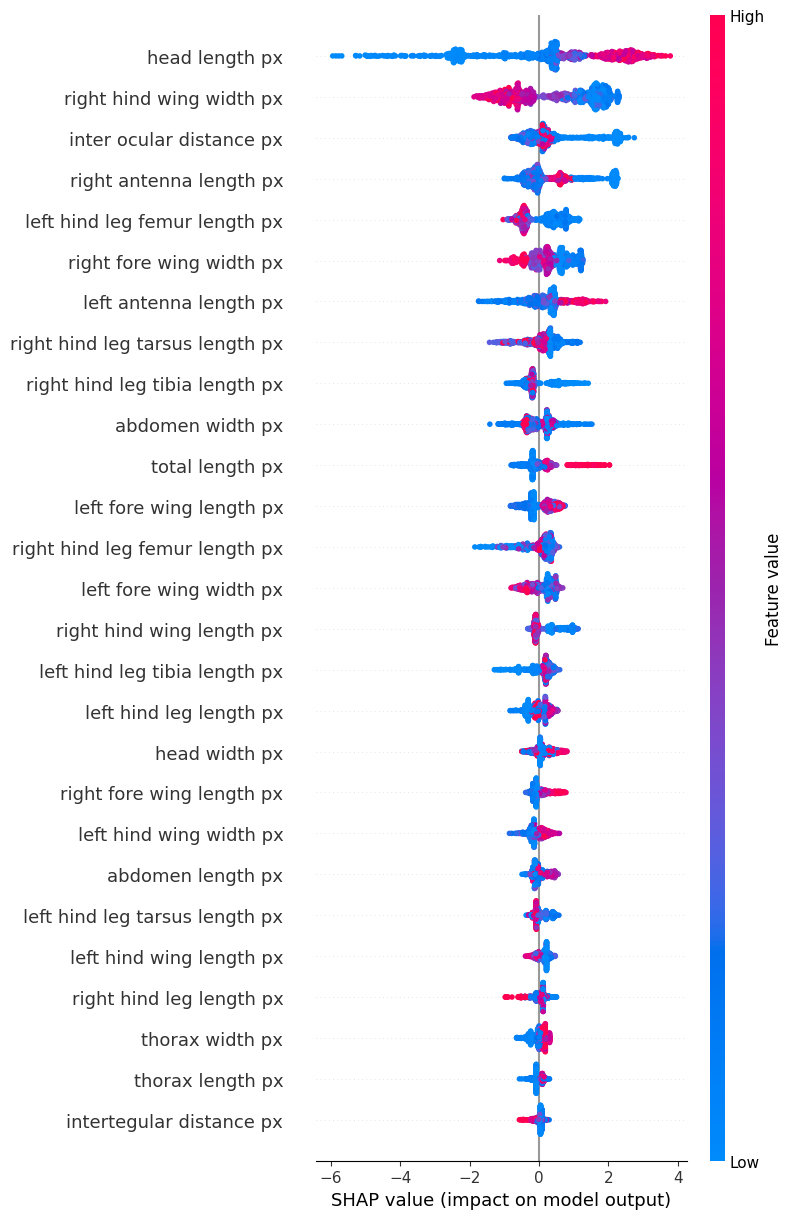

In [33]:
import shap
explainer = shap.TreeExplainer(model)      # pas shap.Explainer
sv = explainer(data_train)
shap.plots.beeswarm(sv, max_display=len(data_train.columns), show=False)
plt.tight_layout()
plt.savefig("test.png", )

In [34]:
# end to end

dtrain = xgb.DMatrix(data_train, label=label_train)
dtest = xgb.DMatrix(data_test, label=label_test)

# parameters
param = {'max_depth': 2, 'eta': 1, 'objective': 'binary:logistic'}
param['nthread'] = 4
param['eval_metric'] = 'auc'

evallist = [(dtrain, 'train'), (dtest, 'eval')]

# training 
num_round = 10
bst = xgb.train(param, dtrain, num_round, evallist)


[0]	train-auc:0.83447	eval-auc:0.83864
[1]	train-auc:0.87238	eval-auc:0.87439
[2]	train-auc:0.89825	eval-auc:0.90775
[3]	train-auc:0.92418	eval-auc:0.91558
[4]	train-auc:0.93434	eval-auc:0.92892
[5]	train-auc:0.94192	eval-auc:0.91374
[6]	train-auc:0.94660	eval-auc:0.91728
[7]	train-auc:0.94977	eval-auc:0.91537
[8]	train-auc:0.95567	eval-auc:0.92286
[9]	train-auc:0.95877	eval-auc:0.91830


c:\Users\tombe\Documents\_MLE\CV-for-GRIT\.venv\Lib\site-packages\xgboost\core.py:566: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

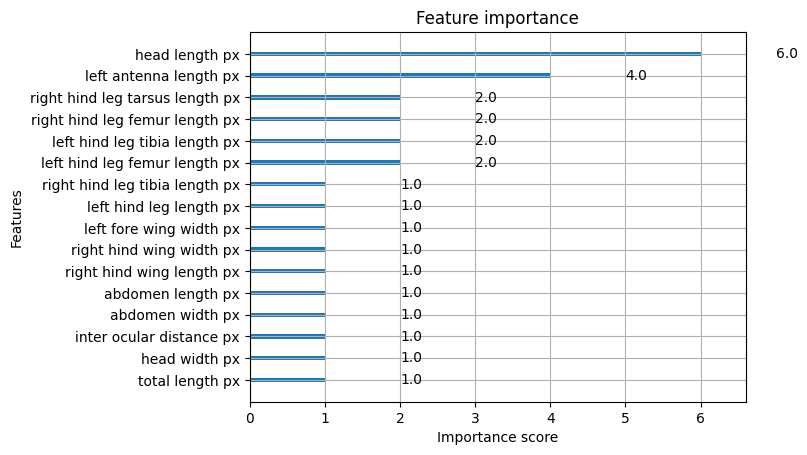

In [35]:
# plots
xgb.plot_importance(bst)

## multiple draws

100%|██████████| 100/100 [00:37<00:00,  2.65it/s]

0.679  (dispersion : 0.178)


(np.float64(0.672486457422977),
 np.float64(0.07783492814691087),
 {'global_mean': np.float64(0.6770092545345324),
  'global_std': np.float64(0.08520342444441707),
  'coleoptera_mean': np.float64(0.984838245317605),
  'coleoptera_std': np.float64(0.012088011460113209),
  'diptera_mean': np.float64(0.9093931612077525),
  'diptera_std': np.float64(0.034936642043266374),
  'hymenoptera_mean': np.float64(0.9561911820303893),
  'hymenoptera_std': np.float64(0.028622758845124316),
  'lepidoptera_mean': np.float64(0.7093157920119053),
  'lepidoptera_std': np.float64(0.058726015426772936)})

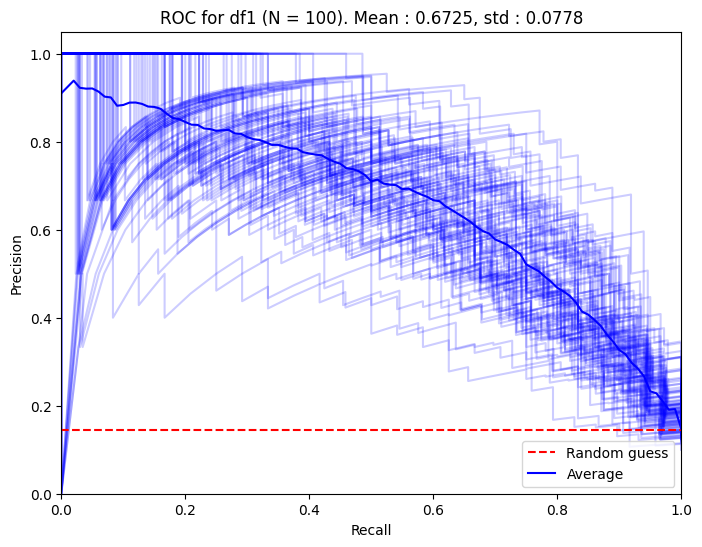

In [ ]:
import tqdm
from sklearn.metrics import accuracy_score, roc_curve, average_precision_score

def draw_multiple_rocs(df, df_name, df_one_hot, model_type, main_measurement, N=1, scale_pos_weight=0.5, show=False, save=False):

    plt.figure(figsize=(8, 6))

    PREVALENCE = 1 - sum(idf[f"{MAIN_MEASURE}_status"]) / len(idf)

    all_fpr = []
    all_tpr = []
    all_auc = []
    all_acc = []
    acc_per_groups = {i:[] for i in INSECTS}

    precision_values = []
    recall_values = []
    threshold_values= []

    for i in tqdm.tqdm(range(N)):
        train, test = train_test_split(df, test_size=0.2)

        data_train = train[[x for x in list(df.columns.values) if "status" not in x and x != "image_name"]].copy()
        data_test = test[[x for x in list(df.columns.values) if "status" not in x and x != "image_name"]].copy()
        # test on head_length
        label_train = train[f"{main_measurement}_status"]
        label_test = test[f"{main_measurement}_status"]

        test_one_hots = df_one_hot.loc[test.index]
        test_one_hots.set_index(test.index, inplace=True)

        if model_type == "xgb":
            model = XGBClassifier(random_state=42, scale_pos_weight = scale_pos_weight)
        elif model_type == "rf":
            model = RandomForestClassifier(random_state=42, class_weight='balanced')
        else:
            print("error : zihggvh")
        model.fit(data_train, label_train)

        y_pred_proba = model.predict_proba(data_test)[:, 1]
        y_pred_values = model.predict(data_test)

        precision, recall, thresholds = precision_recall_curve(1 - label_test, 1 - y_pred_proba)
        AP_score = average_precision_score(1 - label_test, 1 - y_pred_proba)

        precision_values.append(precision)
        recall_values.append(recall)
        threshold_values.append(thresholds)

        # filter negative class = minority class
        pair_results = list(zip(label_test, y_pred_values))
        filtered_label_test = []
        filtered_y_pred_values = []
        filtered_indices = []
        for x in range(len(pair_results)):
            if pair_results[x][1] == 0:
                filtered_label_test.append(pair_results[x][0])
                filtered_y_pred_values.append(pair_results[x][1])
                filtered_indices.append(x)

        acc = accuracy_score(filtered_label_test, filtered_y_pred_values)
        all_acc.append(acc)
        for i in INSECTS:
            acc_group = accuracy_score(label_test[(test_one_hots[f"{i}_one_hot"]==1)], y_pred_values[(test_one_hots[f"{i}_one_hot"]==1)])
            acc_per_groups[i].append(acc_group)

        all_fpr.append(fpr)
        all_tpr.append(tpr)
        all_auc.append(AP_score)

        plt.plot(recall, precision, color='blue', alpha = 0.2)

    all_auc = np.array(all_auc)

    recall_grid = np.linspace(0, 1, 101)
    precisions_interp = []

    for precision, recall in zip(precision_values, recall_values):
        # inversion pour obtenir un rappel croissant
        p, r = precision[::-1], recall[::-1]
        precisions_interp.append(np.interp(recall_grid, r, p))

    precisions_interp = np.array(precisions_interp)   # (n_splits, 101)
    mean_precision = precisions_interp.mean(axis=0)

    seuils = []
    for p, r, t in zip(precision_values, recall_values, threshold_values):
        idx = np.argmin(np.abs(r[:-1] - 0.5))
        seuils.append(t[idx])

    seuil_final = np.median(seuils)
    print(f"{seuil_final:.3f}  (dispersion : {np.std(seuils):.3f})")    
    cible = 0.90
    idx = np.argmin(np.abs(recall[:-1] - cible))
    print(f"seuil={thresholds[idx]:.3f}  rappel={recall[idx]:.3f}  précision={precision[idx]:.3f}")


    plt.plot([0, 1], [PREVALENCE, PREVALENCE], color='red', linestyle='--', label='Random guess')
    plt.plot(recall_grid, mean_precision, color='blue', label='Average')


    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'ROC for {df_name} (N = {N}). Mean : {round(np.mean(all_auc), 4)}, std : {round(np.std(all_auc), 4)}')
    plt.legend(loc="lower right")
    if show:
        plt.show()
    if save:
        plt.savefig(RESULTS_DIR/main_measurement/str(df_name+"_roc.png"))

    acc_infos = {
        "global_mean" : np.mean(all_acc),
        "global_std" : np.std(all_acc),
    }
    for i in INSECTS:
        acc_infos[f"{i}_mean"] = np.mean(acc_per_groups[i])
        acc_infos[f"{i}_std"] = np.std(acc_per_groups[i])

    return np.mean(all_auc), np.std(all_auc), acc_infos

draw_multiple_rocs(df1, "df1", df_one_hot, "xgb", "head length", N=100, save=False)

In [ ]:
# run all feature configuration

to_run = [
    {"name" : "xgb_base_conf", "model_type" : "xgb", "features_group" : "conf", "n_pca" : 0, "related_to_measure" : False, "unique" : False},
    {"name" : "xgb_base_meas", "model_type" : "xgb", "features_group" : "meas", "n_pca" : 0, "related_to_measure" : False, "unique" : False},
    {"name" : "xgb_base_pos", "model_type" : "xgb", "features_group" : "pos", "n_pca" : 0, "related_to_measure" : False, "unique" : False},
    {"name" : "xgb_related_conf", "model_type" : "xgb", "features_group" : "conf", "n_pca" : 0, "related_to_measure" : True, "unique" : False},
    {"name" : "xgb_related_meas", "model_type" : "xgb", "features_group" : "meas", "n_pca" : 0, "related_to_measure" : True, "unique" : False},
    {"name" : "xgb_related_pos", "model_type" : "xgb", "features_group" : "pos", "n_pca" : 0, "related_to_measure" : True, "unique" : False},
    {"name" : "xgb_base_conf", "model_type" : "xgb", "features_group" : "conf", "n_pca" : 0, "related_to_measure" : False, "unique" : False},
    {"name" : "xgb_base_conf_unique", "model_type" : "xgb", "features_group" : "conf", "n_pca" : 0, "related_to_measure" : False, "unique" : True},
    {"name" : "xgb_base_meas_unique", "model_type" : "xgb", "features_group" : "meas", "n_pca" : 0, "related_to_measure" : False, "unique" : True},

    
    {"name" : "rf_base_conf", "model_type" : "rf", "features_group" : "conf", "n_pca" : 0, "related_to_measure" : False, "unique" : False},
    {"name" : "rf_base_meas", "model_type" : "rf", "features_group" : "meas", "n_pca" : 0, "related_to_measure" : False, "unique" : False},
    {"name" : "rf_base_pos", "model_type" : "rf", "features_group" : "pos", "n_pca" : 0, "related_to_measure" : False, "unique" : False},
    {"name" : "rf_related_conf", "model_type" : "rf", "features_group" : "conf", "n_pca" : 0, "related_to_measure" : True, "unique" : False},
    {"name" : "rf_related_meas", "model_type" : "rf", "features_group" : "meas", "n_pca" : 0, "related_to_measure" : True, "unique" : False},
    {"name" : "rf_related_pos", "model_type" : "rf", "features_group" : "pos", "n_pca" : 0, "related_to_measure" : True, "unique" : False},
    {"name" : "rf_base_conf_unique", "model_type" : "rf", "features_group" : "conf", "n_pca" : 0, "related_to_measure" : False, "unique" : True},
    {"name" : "rf_base_meas_unique", "model_type" : "rf", "features_group" : "meas", "n_pca" : 0, "related_to_measure" : False, "unique" : True},
    # {"name" : "pca_conf", "features_group" : "conf", "n_pca" : 5, "related_to_measure" : False},
    # {"name" : "pca_meas", "features_group" : "conf", "n_pca" : 5, "related_to_measure" : False},
    # {"name" : "pca_pos", "features_group" : "conf", "n_pca" : 5, "related_to_measure" : False},
    # {"name" : "base_conf_meas_pos", "features_group" : "conf,meas,pos", "n_pca" : 0, "related_to_measure" : False},
    # {"name" : "related_conf_meas_pos", "features_group" : "conf,meas,pos", "n_pca" : 0, "related_to_measure" : True},
    # {"name" : "pca_conf_meas_pos", "features_group" : "conf,meas,pos", "n_pca" : 10, "related_to_measure" : False},
    # {"name" : "pca_related_conf_meas_pos", "features_group" : "conf,meas,pos", "n_pca" : 5, "related_to_measure" : True},
    # {"name" : "one_hot_conf", "features_group" : "conf,one_hot", "n_pca" : 0, "related_to_measure" : False},
    # {"name" : "one_hot_meas", "features_group" : "meas,one_hot", "n_pca" : 0, "related_to_measure" : False},
    # {"name" : "one_hot_pos", "features_group" : "pos,one_hot", "n_pca" : 0, "related_to_measure" : False},
    # {"name" : "base_one_hot_conf_meas_pos", "features_group" : "conf,meas,pos,one_hot", "n_pca" : 0, "related_to_measure" : False},
    # {"name" : "related_one_hot_conf_meas_pos", "features_group" : "conf,meas,pos,one_hot", "n_pca" : 0, "related_to_measure" : True},
    # {"name" : "pca_one_hot_conf_meas_pos", "features_group" : "conf,meas,pos,one_hot", "n_pca" : 10, "related_to_measure" : False},
    # {"name" : "pca_related_one_hot_conf_meas_pos", "features_group" : "conf,meas,pos,one_hot", "n_pca" : 5, "related_to_measure" : True},
]

MAIN_MEASURE = "head length"

# infos prélis
# général
print("true labels: ", sum(idf[f"{MAIN_MEASURE}_status"]), "/", len(idf))
# par groupe
for n in ["coleoptera", "diptera", "hymenoptera", "lepidoptera"]:
    reduced_df = idf[(idf[f"{n}_one_hot"]==1)].copy()
    print(f"true {n} :", sum(reduced_df[f"{MAIN_MEASURE}_status"]), "/", len(reduced_df))

SCALE_POS_WEIGHT = sum(idf[f"{MAIN_MEASURE}_status"]) / len(idf)

all_datas = {"run_name" : [], "AUC_mean" : [], "AUC_std": [], "acc_global_mean" : [], "acc_global_std" : []}
for i in INSECTS:
    all_datas[f"acc_{i}_mean"] = []
    all_datas[f"acc_{i}_std"] = []

results = []

for run in to_run :
    print("-------")
    print(f"Running {run["name"]}")
    print("creating df") 
    df = create_df(run["features_group"], unique=run["unique"], n_pca=run["n_pca"], related_to_measure=MAIN_MEASURE if run["related_to_measure"] else "")

    print("calculating shap")
    train, test = train_test_split(df, test_size=0.2)

    data_train = train[[x for x in list(df.columns.values) if "status" not in x and x != "image_name"]].copy()
    data_test = test[[x for x in list(df.columns.values) if "status" not in x and x != "image_name"]].copy()

    label_train = train[f"{MAIN_MEASURE}_status"]
    label_test = test[f"{MAIN_MEASURE}_status"]

    model_type = run["model_type"]

    if model_type == "xgb":
        model = XGBClassifier(random_state=42, scale_pos_weight = SCALE_POS_WEIGHT)
    elif model_type == "rf":
        model = RandomForestClassifier(random_state=42, class_weight='balanced')

    model.fit(data_train, label_train)

    explainer = shap.TreeExplainer(model)      
    sv = explainer(data_train)
    shap.plots.beeswarm(sv, max_display=len(data_train.columns), show=False)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR/ MAIN_MEASURE/ f"{run["name"]}_shap.png")
    plt.clf()

    print("draw rocs")
    mean, std, acc_infos = draw_multiple_rocs(df, run["name"], df_one_hot, model_type, MAIN_MEASURE, N=100, scale_pos_weight=SCALE_POS_WEIGHT, save=True)
    plt.clf()

    plt.bar(["Global"] + INSECTS, [v for k, v in acc_infos.items() if "mean" in k], yerr = [v for k, v in acc_infos.items() if "std" in k])
    plt.tight_layout()
    plt.savefig(RESULTS_DIR/MAIN_MEASURE/f"{run["name"]}_acc")
    plt.clf()

    del model

    all_datas["run_name"].append(run["name"])

    all_datas["AUC_mean"].append(mean)
    all_datas["AUC_std"].append(std)
    
    all_datas["acc_global_mean"].append(acc_infos["global_mean"])
    all_datas["acc_global_std"].append(acc_infos["global_std"])
    
    for i in INSECTS:
        all_datas[f"acc_{i}_mean"].append(acc_infos[f"{i}_mean"])
        all_datas[f"acc_{i}_std"].append(acc_infos[f"{i}_std"])

all_datas = pd.DataFrame(all_datas)
all_datas.to_csv(RESULTS_DIR/MAIN_MEASURE/"results.csv")

true labels:  1024 / 1198
true coleoptera : 384 / 397
true diptera : 267 / 287
true hymenoptera : 229 / 240
true lepidoptera : 144 / 274
-------
Running base_conf
creating df
calculating shap
draw rocs


100%|██████████| 100/100 [00:44<00:00,  2.26it/s]


-------
Running base_meas
creating df
calculating shap
draw rocs


100%|██████████| 100/100 [00:48<00:00,  2.05it/s]


-------
Running base_pos
creating df
calculating shap
draw rocs


100%|██████████| 100/100 [01:26<00:00,  1.16it/s]


-------
Running related_conf
creating df
calculating shap
draw rocs


100%|██████████| 100/100 [00:41<00:00,  2.39it/s]


-------
Running related_meas
creating df
calculating shap
draw rocs


100%|██████████| 100/100 [00:42<00:00,  2.33it/s]


-------
Running related_pos
creating df
calculating shap
draw rocs


100%|██████████| 100/100 [00:58<00:00,  1.70it/s]


<Figure size 800x1830 with 0 Axes>

<Figure size 800x1230 with 0 Axes>

<Figure size 800x3510 with 0 Axes>

<Figure size 800x750 with 0 Axes>

<Figure size 800x710 with 0 Axes>

<Figure size 800x1350 with 0 Axes>

<Figure size 800x600 with 0 Axes>

# optimisation

In [ ]:
model_xgb = XGBClassifier()

param_grid = {'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 10]}
grid_search = GridSearchCV(model_xgb, param_grid, cv=5)

# Entraînement sur les données
grid_search.fit(data_train, label_train)

# Meilleur modèle avec l'hyperparamètre optimal
model_xgb_params = grid_search.best_params_
print("Meilleurs paramètres :", model_xgb_params)

# Évaluation sur les données de test
score = grid_search.score(data_test, label_test)
print("Score sur les données de test :", score)

Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Score sur les données de test : 0.9333333333333333


In [ ]:
def objective_GradientBoosting(trial):

    n_estimators = trial.suggest_int("n_estimators", 2, 20)
    max_depth = int(trial.suggest_float("max_depth", 1, 32, log=True))
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)

    clf = XGBClassifier(n_estimators=n_estimators, 
                                    max_depth=max_depth, 
                                    learning_rate=learning_rate,
                                    random_state = 42)

    return cross_val_score(
        clf, data_train, label_train, n_jobs=-1, scoring='roc_auc', cv=3
    ).mean()

study_GradientBoosting = optuna.create_study(direction="maximize", seed=42)
study_GradientBoosting.optimize(objective_GradientBoosting, n_trials=100)

TypeError: create_study() got an unexpected keyword argument 'seed'

In [ ]:
import numpy as np
df = study_GradientBoosting.trials_dataframe()
print(df["value"].describe())   # si l'écart max-min est ~0.02, il n'y a rien à gagner

# puis : mêmes hyperparamètres, 10 seeds de CV différents
from sklearn.model_selection import StratifiedKFold
scores = [cross_val_score(XGBClassifier(n_estimators= 19, max_depth= 24, learning_rate=0.19104809931724484, random_state=0),
                          data_train, label_train, scoring="roc_auc",
                          cv=StratifiedKFold(3, shuffle=True, random_state=s)).mean()
          for s in range(10)]
print(np.std(scores))

count    300.000000
mean       0.908481
std        0.007556
min        0.862293
25%        0.906025
50%        0.909991
75%        0.913320
max        0.922954
Name: value, dtype: float64
0.007957408754627566


In [ ]:

trial_GradientBoosting = study_GradientBoosting.best_trial
print("GradientBoosting (RMSE): {}".format(trial_GradientBoosting.value))
print("Best hyperparameters: {}".format(trial_GradientBoosting.params))

GradientBoosting (RMSE): 0.9229538897342769
Best hyperparameters: {'n_estimators': 19, 'max_depth': 24.35952234841416, 'learning_rate': 0.19104809931724484}
